In [1]:
# python
import sys
import os
import importlib
import numpy as np
# columnar analysis
import awkward as ak
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from coffea import processor
# local
sys.path.insert(1, os.path.join(sys.path[0], '../..')) # fixme: there must be a better way to handle this...
from sidm.tools import sidm_processor, utilities
# always reload local modules to pick up changes during development
importlib.reload(sidm_processor)
importlib.reload(utilities)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline

In [2]:
samples = [
    '4Mu_500GeV_5p0GeV_0p08mm',
    #'2mu2e_500GeV_5p0GeV_0p08mm',
]
fileset = utilities.make_fileset(samples, "llpNanoAOD_v2", max_files=1)
# create events collection from single file
fname = fileset[samples[0]][0]
print(fname)
events = NanoEventsFactory.from_root(
    fname,
    schemaclass=NanoAODSchema,
).events()

root://xcache//store/group/lpcmetx/SIDM/ULSignalSamples/2018_v8/LLPNanoAOD_V2/SIDM_BsTo2DpTo4Mu_MBs-500_MDp-5p0_ctau-0p08_v3/LLPnanoAODv2/SIDM_BsTo2DpTo4Mu_MBs-500_MDp-5p0_ctau-0p08_v3_part-1.root


In [3]:
#ak.fields(events)

In [4]:
#/store/group/lpcmetx/SIDM/ULSignalSamples/2018_v3/signals/SIDM_BsTo2DpTo4Mu_MBs-500_MDp-5p0_ctau-0p08/LLPnanoAOD/SIDM_BsTo2DpTo4Mu_MBs-500_MDp-5p0_ctau-0p08_part-0.rootak.fields(events.Muon)

In [24]:
print(events.fields)

['L1Reco', 'fixedGridRhoFastjetCentralCalo', 'GenPart', 'SubGenJetAK8', 'GenIsolatedPhoton', 'IsoTrack', 'SV', 'fixedGridRhoFastjetAll', 'Photon', 'fixedGridRhoFastjetCentral', 'SoftActivityJet', 'DSAMuonVertexRefittedTracks', 'L1PreFiringWeight', 'LHEPdfWeight', 'DSAMuon', 'GenMET', 'PuppiMET', 'BS', 'GenVtx', 'LowPtElectron', 'HLTriggerFinalPath', 'Tau', 'genWeight', 'Flag', 'boostedTau', 'LHE', 'MET', 'RawPuppiMET', 'PatDSAMuonVertex', 'event', 'GenDressedLepton', 'genTtbarId', 'LHEPart', 'SubJet', 'OtherPV', 'CaloMET', 'DeepMETResolutionTune', 'btagWeight', 'SoftActivityJetNjets2', 'SoftActivityJetNjets5', 'SoftActivityJetHT', 'L1simulation', 'PatMuonVertex', 'DSAMuonVertex', 'run', 'Electron', 'fixedGridRhoFastjetCentralNeutral', 'PSWeight', 'HLT', 'GenJet', 'FatJet', 'SoftActivityJetNjets10', 'LHEWeight', 'PatDSAMuonVertexRefittedTracks', 'fixedGridRhoFastjetCentralChargedPileUp', 'PV', 'DeepMETResponseTune', 'LHEScaleWeight', 'ChsMET', 'SoftActivityJetHT2', 'TrigObj', 'Jet', 'Ge

In [6]:
print(events.PV.fields)
print(events.PV.pos.rho)
print(events.PV.x)
print(events.PV.y)
print(events.BS)
print(events.BS.fields)
print(events.BS.x)
print(events.BS.y)
print(utilities.rho(events.PV, ref=events.BS))
print(events.PV)
print(events.PV.npvs)
print(events.PV.ndof)
print(len(events.PV.z < 24))
print(len(events.Muon.pt > 100))
print(events.MET)
print(events.MET.fields)
print(ak.count([1, 2, 3], keepdims=False))
print(events.PV.ndim)
print(events.MET.ndim)
print(events.Muon.ndim)
print(ak.ones_like(events.MET.x, dtype=np.int32))
print(ak.unflatten(events.MET, ak.ones_like(events.MET.x, dtype=np.int32)))
print(events.MET.fields)
print(events.PV.fields)
print(events.genWeight.fields)
print(events.event.fields)

['ndof', 'x', 'y', 'z', 'chi2', 'score', 'npvs', 'npvsGood']
[2.66, 0.685, 3.2, 4.06, 0.967, 1.88, 0.116, ... 0.885, 1.97, 0.601, 5.08, 4.9, 1.06]
[0.0103, 0.0107, 0.0113, 0.0118, 0.0085, ... 0.00984, 0.014, 0.013, 0.0109, 0.0107]
[0.0407, 0.0419, 0.041, 0.0403, 0.044, ... 0.0416, 0.0436, 0.0403, 0.0411, 0.041]
[[{x: 0.0108, y: 0.0419, z: 0.0249, ndof: 0, chi2: 0, ... chi2: 0, ntracks: 0}]]
['x', 'y', 'z', 'ndof', 'chi2', 'ntracks']
[[0.0108], [0.0108], [0.0108], [0.0108], ... [0.0108], [0.0108], [0.0108], [0.0108]]
[[0.0419], [0.0419], [0.0419], [0.0419], ... [0.0419], [0.0419], [0.0419], [0.0419]]
[[0.00131], [5.74e-05], [0.00101], ... [0.00274], [0.000792], [0.000884]]
[Vertex, Vertex, Vertex, Vertex, Vertex, ... Vertex, Vertex, Vertex, Vertex, Vertex]
[28, 25, 33, 28, 34, 18, 17, 29, 19, 33, ... 17, 36, 38, 26, 29, 16, 25, 29, 8, 28]
[152, 53.9, 154, 47.6, 47.9, 91.2, 34.2, ... 89.8, 117, 71.2, 4.83, 22.2, 70.5, 131]
1986
1986
[MissingET, MissingET, MissingET, MissingET, ... Missin

In [7]:
print(events.GenPart.fields)
print(events.GenPart.pdgId)
print(ak.num(events.GenPart[abs(events.GenPart.pdgId)==13]))
genAs = events.GenPart[abs(events.GenPart.pdgId)==32]
print(ak.num(genAs))
print(genAs.children.pdgId)
print(abs(events.GenPart.pdgId))
print(ak.all(abs(genAs.children.pdgId) == 13, axis=-1))
print((genAs - genAs.children[:, 0]).r)
genAs_toE = genAs[ak.all(abs(genAs.children.pdgId) == 11, axis=-1)]
genAs_toMu = genAs[ak.all(abs(genAs.children.pdgId) == 13, axis=-1)]
print(genAs_toMu)
print((genAs_toMu - genAs_toMu.children[:, 0]).r)
genAs_toE = genAs_toE[ak.num(genAs_toE) > 0]
print(genAs_toE)
print((genAs_toE - genAs_toE.children[:, 0]).r)

['eta', 'mass', 'phi', 'pt', 'genPartIdxMother', 'pdgId', 'status', 'statusFlags', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'genPartIdxMotherG', 'distinctParentIdxG', 'childrenIdxG', 'distinctChildrenIdxG', 'distinctChildrenDeepIdxG']
[[-4, 4, 35, 35, 32, 32, -13, 13, -13, ... 13, -413, 1, -1, 413, -421, 421, 11, -11]]
[4, 4, 4, 4, 6, 4, 6, 5, 4, 6, 8, 5, 6, 6, ... 6, 4, 4, 5, 4, 6, 6, 8, 6, 5, 4, 7, 4]
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ... 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
[[[-13, 13], [-13, 13]], [[-13, 13], [-13, ... [-13, 13]], [[-13, 13], [-13, 13]]]
[[4, 4, 35, 35, 32, 32, 13, 13, 13, 13, ... 13, 413, 1, 1, 413, 421, 421, 11, 11]]
[[True, True], [True, True], [True, True, ... True], [True, True], [True, True]]
[[175, 417], [139, 350], [60, 111], [220, ... [132, 364], [96.3, 325], [16, 230]]
[[GenParticle, GenParticle], [GenParticle, ... [GenParticle, GenParticle]]
[[175, 417], [139, 350], [60, 111], [220, ... [132, 364], [96.3, 325], [16, 230]]
[]
[]


In [8]:
#events.Electron.fields

In [9]:
events[ak.num(events.Electron)>0].Electron.vidNestedWPBitmap

<Array [[605177636], ... [605028452]] type='288 * var * int32[parameters={"__doc...'>

In [10]:
#events.DSAMuon.fields

In [11]:
print(events.DSAMuon.muonMatch1)
print(events.DSAMuon.nSegments)
print(ak.num(events.DSAMuon))
print(ak.num(events.DSAMuon[events.DSAMuon.muonMatch1/events.DSAMuon.nSegments < 0.667]))

[[7, 6, 0], [3, 4, 4, 7], [3, 4, 3], [0, ... 0, 4], [4, 4, 4, 4, 0], [0, 2, 3, 2, 4]]
[[7, 8, 1], [4, 4, 4, 7], [3, 4, 3], [0, ... 3, 4], [4, 4, 4, 4, 1], [5, 2, 3, 2, 4]]
[3, 4, 3, 6, 5, 4, 5, 7, 6, 4, 3, 4, 5, 4, ... 4, 5, 4, 6, 5, 6, 5, 3, 4, 6, 4, 5, 5]
[1, 0, 0, 0, 1, 0, 0, 2, 2, 0, 0, 0, 1, 0, ... 0, 2, 0, 3, 1, 4, 1, 0, 0, 2, 1, 1, 1]


/opt/conda/lib/python3.9/site-packages/awkward/_connect/_numpy.py:195: RuntimeWarning: invalid value encountered in divide
  result = getattr(ufunc, method)(


In [12]:
#print(events.DSAMuon.muonMatch1[0])
print(set(ak.flatten(events.DSAMuon.muonMatch1idx)))
print(events.DSAMuon[0])
print(events.Muon[0])
print(events.Muon[ak.values_astype(events.DSAMuon.muonMatch1idx, "int64")])
a = ak.Array([[0, 1, 0], [1]])
b = ak.Array([[71, 72], [59, 58, 57]])
b[a]

{0.0, 1.0, 2.0, 3.0, 4.0}
[{idx: 0, pt: 69.8, ptErr: 20.6, eta: 1.89, ... nDTSegments: 1, nCSCSegments: 0}]
[Muon, Muon, Muon, Muon]
[[Muon, Muon, Muon], [Muon, Muon, Muon, ... Muon], [Muon, Muon, Muon, Muon, Muon]]


<Array [[71, 72, 71], [58]] type='2 * var * int64'>

In [13]:
print(events.DSAMuon.muonMatch1)
print(events.DSAMuon.muonMatch1idx)
print(ak.flatten(events.DSAMuon.muonMatch1idx))
#print(events.DSAMuon.outerPhi)
print(events.Muon.outerPhi)
print(events.Muon[ak.values_astype(events.DSAMuon.muonMatch1idx, "int64")].outerPhi)
utilities.dR_outer(events.DSAMuon, events.Muon[ak.values_astype(events.DSAMuon.muonMatch1idx, "int64")])

[[7, 6, 0], [3, 4, 4, 7], [3, 4, 3], [0, ... 0, 4], [4, 4, 4, 4, 0], [0, 2, 3, 2, 4]]
[[2, 0, 3], [2, 0, 2, 3], [1, 3, 4], [3, ... 3, 1], [2, 0, 1, 3, 3], [3, 3, 1, 0, 2]]
[2, 0, 3, 2, 0, 2, 3, 1, 3, 4, 3, 0, 3, 0, ... 0, 3, 1, 2, 0, 1, 3, 3, 3, 3, 1, 0, 2]
[[-1.84, 1.29, 1.3, -1.81], [-1.95, 1.63, ... -3.1], [1.85, -1.27, 1.98, -1.52]]
[[1.3, -1.84, -1.81], [1.68, -1.95, 1.68, ... [-1.52, -1.52, -1.27, 1.85, 1.98]]


<Array [[0.00467, 0.277, ... 0.0215, 0.000869]] type='1986 * var * float32'>

In [14]:
#from coffea.nanoevents.schemas.base import zip_forms
from coffea.nanoevents.methods import vector as cvec
from coffea.nanoevents.methods import nanoaod
#print(events.Muon)
#print([events.DSAMuon[x] for x in ["pt", "eta"]])
print(events.DSAMuon)
forms = {f : events.DSAMuon[f] for f in events.DSAMuon.fields}
events.DSAMuon = ak.zip(forms, with_name="Muon", behavior=nanoaod.behavior)
print(events.DSAMuon)
print(events.DSAMuon.nearest(events.Muon))

[[{idx: 0, pt: 69.8, ptErr: 20.6, eta: 1.89, ... nDTSegments: 4, nCSCSegments: 0}]]
[[Muon, Muon, Muon], [Muon, Muon, Muon, ... Muon], [Muon, Muon, Muon, Muon, Muon]]
[[Muon, Muon, Muon], [Muon, Muon, Muon, ... Muon], [Muon, Muon, Muon, Muon, Muon]]


In [15]:
#g = events.GenPart
#print(g)
#print(ak.count(g))
#print(ak.num(g, axis=1))
#print(ak.num(g, axis=0))
#print(ak.num(g.children, axis=2))
#g = g[ak.num(g.children, axis=2) > 0]
#print(g.children[ak.num(g.children, axis=2) > 0][:, :, 0])
#print(ak.count(ak.num(g.children, axis=2) > 0))
#print(g.children[:, :, 0])
#print((g - g.children[:, :, 0]))
#print(ak.num(g.children))
#print(ak.firsts(g.children))
#print(ak.num(ak.firsts(g.children)))
#print(~ak.is_none(ak.firsts(g.children)))
#print((g - g.children[:, :, 0]).r)
#print(g.pdgId)
#zd = g[g.pdgId == 32]
#ak.num(zd.children)
#print(zd)
#zd_lxy = (zd - ak.firsts(zd.children)).r
#print(zd_lxy)
#print(ak.num(zd_lxy, axis=1))
zd = events.GenPart[abs(events.GenPart.pdgId) == 32]
print(zd)
print(ak.num(zd))

[[GenParticle, GenParticle], [GenParticle, ... [GenParticle, GenParticle]]
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ... 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [16]:
runner = processor.Runner(
    executor=processor.IterativeExecutor(),
    #executor=processor.FuturesExecutor(),
    schema=NanoAODSchema,
    maxchunks=1,
)

channels = [
        #"llpnano",
        #"4mu",
        #"baseNoLj_A_mumu_matched_lj",
        "baseNoLj",
]
p = sidm_processor.SidmProcessor(
    channels,
    ["base_plus_gen"],
    #verbose=True,
)

output = runner.run(fileset, treename='Events', processor_instance=p)
out = output["out"]

Output()

Output()

Warning: zero genAs_toE objects found in this sample. Skipping.

baseNoLj {'obj': {'electrons': ['pT > 10 GeV', '|eta| < 2.4', 'looseID'], 'muons': ['looseID', 'pT > 5 GeV', '|eta|
< 2.4'], 'photons': ['pT > 20 GeV', '|eta| < 2.5', 'looseID'], 'dsaMuons': ['pT > 10 GeV', '|eta| < 2.4', 'DT + CSC
hits > 12', 'ifcsczero', 'normChi2 < 2.5', 'ptErrorOverPT < 1', 'no PF match'], 'pvs': ['ndof > 4', '|z| < 24 cm', 
'|rho| < 0.02 cm'], 'genMus': ['status == 1'], 'genEs': ['status == 1']}, 'lj': {}, 'postLj_obj': {}, 'evt': ['PV 
filter']}

/opt/conda/lib/python3.9/site-packages/awkward/_connect/_numpy.py:195: RuntimeWarning: invalid value encountered in
divide
  result = getattr(ufunc, method)(

...

Warning: a histogram with the name genAs_toE_matched_egmLj_pt_highRange could not be filled and will be skipped

Warning: a histogram with the name genAs_toE_matched_egmLj_eta could not be filled and will be skipped

Warning: a histogram with the name genAs_toE_matched_egmLj_n could not be filled and will be skipped

Warning: cannot fill counter Gen As to electrons. Skipping.

Warning: cannot fill counter Matched gen As to electrons. Skipping.

In [17]:
hists = out[samples[0]]["hists"]

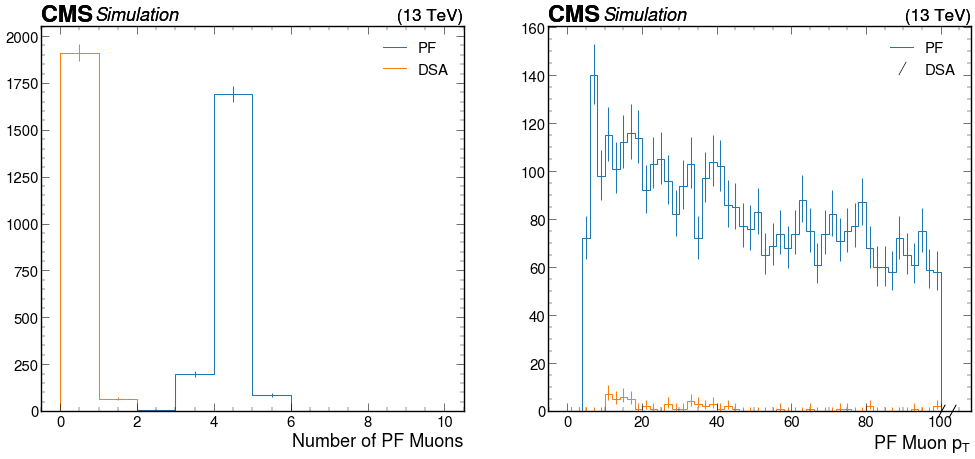

In [18]:
ch = channels[0]
plt.subplots(1, 2, figsize=(24, 10))
plt.subplot(1, 2, 1)
utilities.plot(hists["muon_n"][ch, :])
utilities.plot(hists["dsaMuon_n"][ch, :])
plt.legend(["PF", "DSA"])
plt.subplot(1, 2, 2)
utilities.plot(hists["muon_pt"][ch, ::2j])
utilities.plot(hists["dsaMuon_pt"][ch, ::2j])
plt.legend(["PF", "DSA"])

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f6a827d9820>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

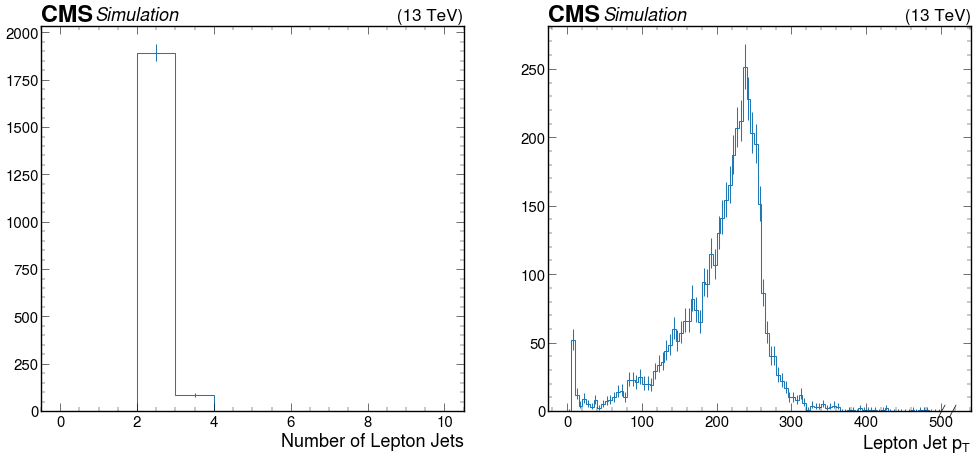

In [19]:
plt.subplots(1, 2, figsize=(24, 10))
plt.subplot(1, 2, 1)
utilities.plot(hists["lj_n"][ch, :])
plt.subplot(1, 2, 2)
utilities.plot(hists["lj_pt"][ch, :])

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f6a8bc4e550>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

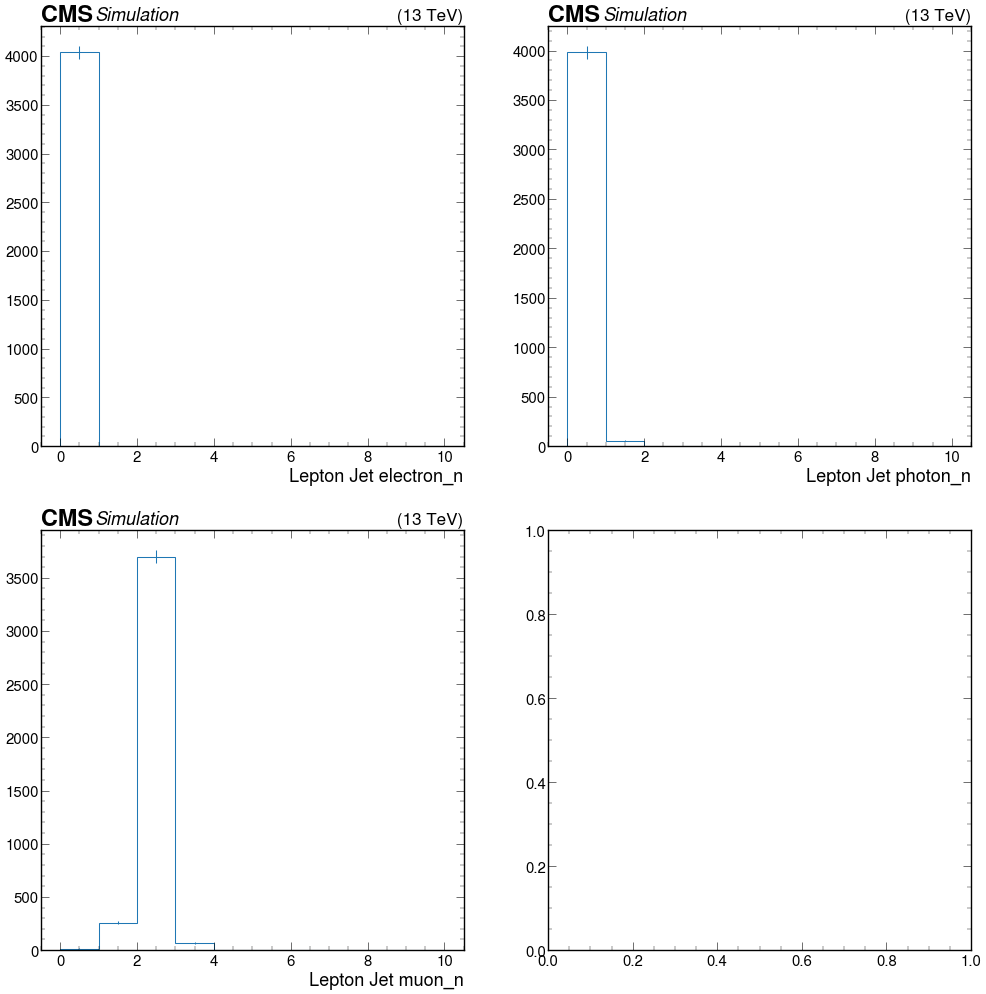

In [20]:
plt.subplots(2, 2, figsize=(24, 24))
plt.subplot(2, 2, 1)
utilities.plot(hists["lj_electronN"][ch, :])
plt.subplot(2, 2, 2)
utilities.plot(hists["lj_photonN"][ch, :])
plt.subplot(2, 2, 3)
utilities.plot(hists["lj_muonN"][ch, :])
#plt.subplot(2, 2, 4)
#utilities.plot(hists["lj_dsaMuonN"][ch, :])

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f6aa94926d0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

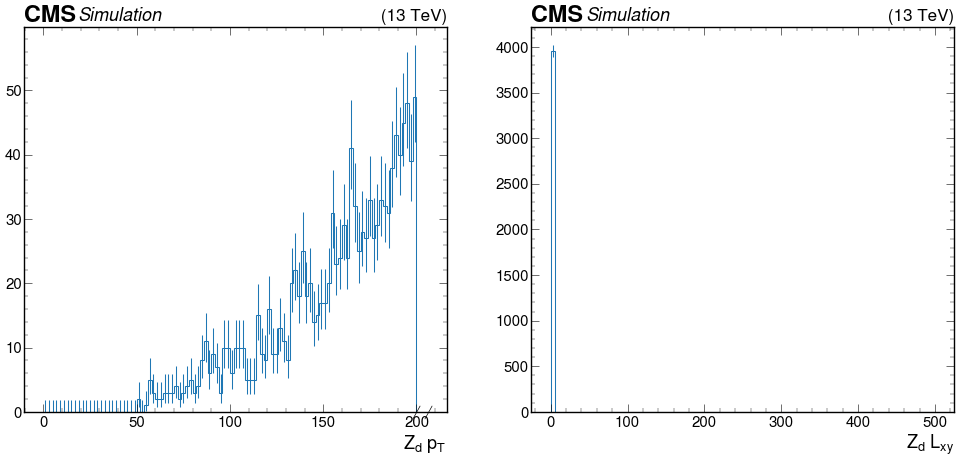

In [21]:
plt.subplots(1, 2, figsize=(24, 10))
plt.subplot(1, 2, 1)
utilities.plot(hists["genAs_pt"][ch, :])
plt.subplot(1, 2, 2)
utilities.plot(hists["genAs_lxy"][ch, :])

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f6a8258ee50>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

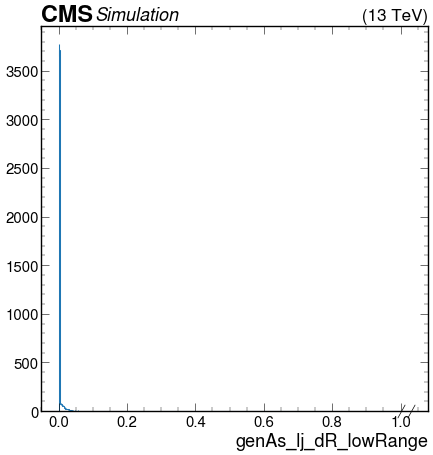

In [22]:
utilities.plot(hists["genAs_lj_dR_lowRange"][ch, :])